# Import Statements

In [1]:
import pandas as pd
import numpy as np
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from statsmodels.stats.inter_rater import fleiss_kappa

# Reading the Responses

In [2]:
experts_biology_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/dragonfly_forms_reliability/responses/ExpertsBiology_Responses.csv")
experts_cs_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/dragonfly_forms_reliability/responses/ExpertsCS_Responses.csv")

In [3]:
print(experts_biology_df.shape)
print(experts_cs_df.shape)

(11, 452)
(9, 452)


# Cleaning up the responses

## Bio

In [4]:
index_bio = pd.RangeIndex(start=1, stop=10)
setting_index_bio = index_bio.map(lambda x: f"Respondent {x}")

In [5]:
score_columns_bio = experts_biology_df.columns[experts_biology_df.columns.str.contains('Score')]
feedback_columns_bio = experts_biology_df.columns[experts_biology_df.columns.str.contains('Feedback')]
score_and_feedback_columns = list(score_columns_bio) + list(feedback_columns_bio)

experts_biology_df.drop(columns=score_and_feedback_columns, inplace=True)

# dropping the first two rows, as they contain responses for only 100 images
experts_biology_df = experts_biology_df.iloc[2:, :]

# dropping the timestamp and the default score column as well
experts_biology_df.drop(columns=['Tijdstempel', 'Totale score'], inplace=True)
experts_biology_df.reset_index(drop=True, inplace=True)
experts_biology_df.index = setting_index_bio

## CS

In [7]:
experts_cs_df.head(5)

,Tijdstempel,Totale score,Do you agree with the classification?,Do you agree with the classification? [Score],Do you agree with the classification? [Feedback],Do you agree with the classification?.1,Do you agree with the classification? [Score].1,Do you agree with the classification? [Feedback].1,Do you agree with the classification?.2,Do you agree with the classification? [Score].2,...,Do you agree with the classification? [Feedback].146,Do you agree with the classification?.147,Do you agree with the classification? [Score].147,Do you agree with the classification? [Feedback].147,Do you agree with the classification?.148,Do you agree with the classification? [Score].148,Do you agree with the classification? [Feedback].148,Do you agree with the classification?.149,Do you agree with the classification? [Score].149,Do you agree with the classification? [Feedback].149
0,2025/11/25 2:15:58 p.m. CET,0.00 / 0,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,...,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN
1,2025/12/04 4:57:30 p.m. CET,0.00 / 0,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,...,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN
2,2025/12/05 4:38:02 p.m. CET,0.00 / 0,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,...,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN
3,2025/12/11 6:25:11 p.m. CET,0.00 / 0,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,...,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN
4,2025/12/11 6:45:23 p.m. CET,0.00 / 0,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,NaN,"Yes, only all seven parts (the head, thorax, a...",-- / 0,...,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN,"Yes, the three main parts (the head, thorax an...",-- / 0,NaN,"No, one or more of the three main parts (the h...",-- / 0,NaN


In [8]:
index_cs = pd.RangeIndex(start=1, stop=10)
setting_index_cs = index_cs.map(lambda x: f"Respondent {x}")

In [9]:
score_columns_cs = experts_cs_df.columns[experts_cs_df.columns.str.contains('Score')]
feedback_columns_cs = experts_cs_df.columns[experts_cs_df.columns.str.contains('Feedback')]
score_and_feedback_columns_cs = list(score_columns_cs) + list(feedback_columns_cs)

experts_cs_df.drop(columns=score_and_feedback_columns_cs, inplace=True)

# dropping the timestamp and the default score column as well
experts_cs_df.drop(columns=['Tijdstempel', 'Totale score'], inplace=True)
experts_cs_df.reset_index(drop=True, inplace=True)
experts_cs_df.index = setting_index_cs

# Totalling the Overall Responses

In [10]:
max_width = 25

## Bio

In [11]:
total_of_responses_bio = experts_biology_df.apply(pd.Series.value_counts, axis=1).fillna(0)
total_of_responses_bio.shape

(9, 5)

In [12]:
total_of_responses_bio

,"No, one of the three main parts (the head, thorax and abdomen) is misclassified","No, one or more of the three main parts (the head, thorax and abdomen) is not detected in the image","Yes, all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model. In addition to this, there are other objects misrecognized by the model.","Yes, only all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model","Yes, the three main parts (the head, thorax and abdomen) are recognised, and there can be some discrepancies with the wings, and/or some misrecognised objects"
Respondent 1,26,41,9,37,37
Respondent 2,6,67,1,32,43
Respondent 3,16,54,20,35,25
Respondent 4,9,64,2,41,34
Respondent 5,21,46,14,30,39
Respondent 6,42,45,12,25,25
Respondent 7,9,68,10,27,36
Respondent 8,15,54,14,41,26
Respondent 9,4,70,13,26,37


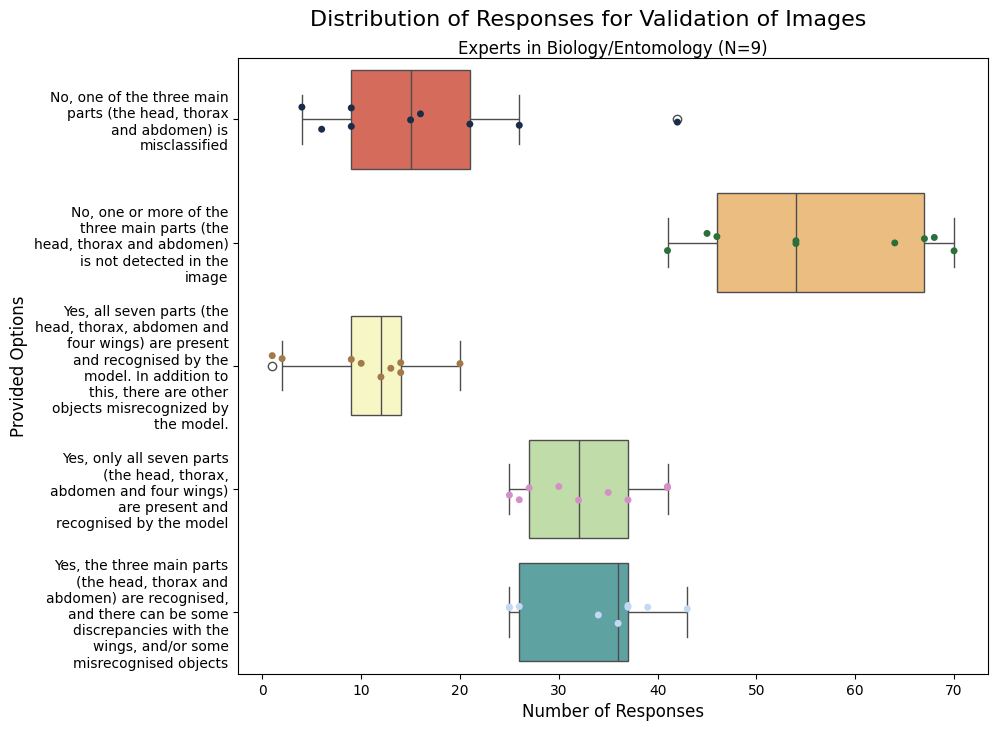

In [33]:
fig, axs = plt.subplots(figsize=(10, 8))
sns.boxplot(ax=axs, data=total_of_responses_bio,zorder=0, orient='h', palette='Spectral')
sns.stripplot(ax=axs, data=total_of_responses_bio, zorder=1, orient='h', palette='cubehelix')

plt.suptitle("Distribution of Responses for Validation of Images", fontsize=16, y=0.94)
axs.set_title("Experts in Biology/Entomology (N=9)", fontsize=12, pad=2)

axs.set_xlabel("Number of Responses", fontsize=12)
axs.set_ylabel("Provided Options", fontsize=12)
labels = [textwrap.fill(label.get_text(), max_width) for label in axs.get_yticklabels()]
ticks = axs.get_yticks()
axs.set_yticks(ticks)
axs.set_yticklabels(labels, fontsize=10)
plt.subplots_adjust(left=0.15)

# plt.savefig("/home/mrajaraman/master-thesis-dragonfly/dragonfly_forms_reliability/responses_distribution_bio_experts.png", dpi=300)
plt.show()

## CS

In [14]:
total_of_responses_cs = experts_cs_df.apply(pd.Series.value_counts, axis=1).fillna(0)
total_of_responses_cs.shape

(9, 5)

In [34]:
total_of_responses_cs

,"No, one of the three main parts (the head, thorax and abdomen) is misclassified","No, one or more of the three main parts (the head, thorax and abdomen) is not detected in the image","Yes, all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model. In addition to this, there are other objects misrecognized by the model.","Yes, only all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model","Yes, the three main parts (the head, thorax and abdomen) are recognised, and there can be some discrepancies with the wings, and/or some misrecognised objects"
Respondent 1,11,63,3,34,38
Respondent 2,12,56,9,21,52
Respondent 3,24,51,13,26,36
Respondent 4,20,60,14,36,20
Respondent 5,19,48,22,36,25
Respondent 6,18,57,23,30,22
Respondent 7,7,51,16,53,23
Respondent 8,22,51,1,47,29
Respondent 9,10,62,21,37,20


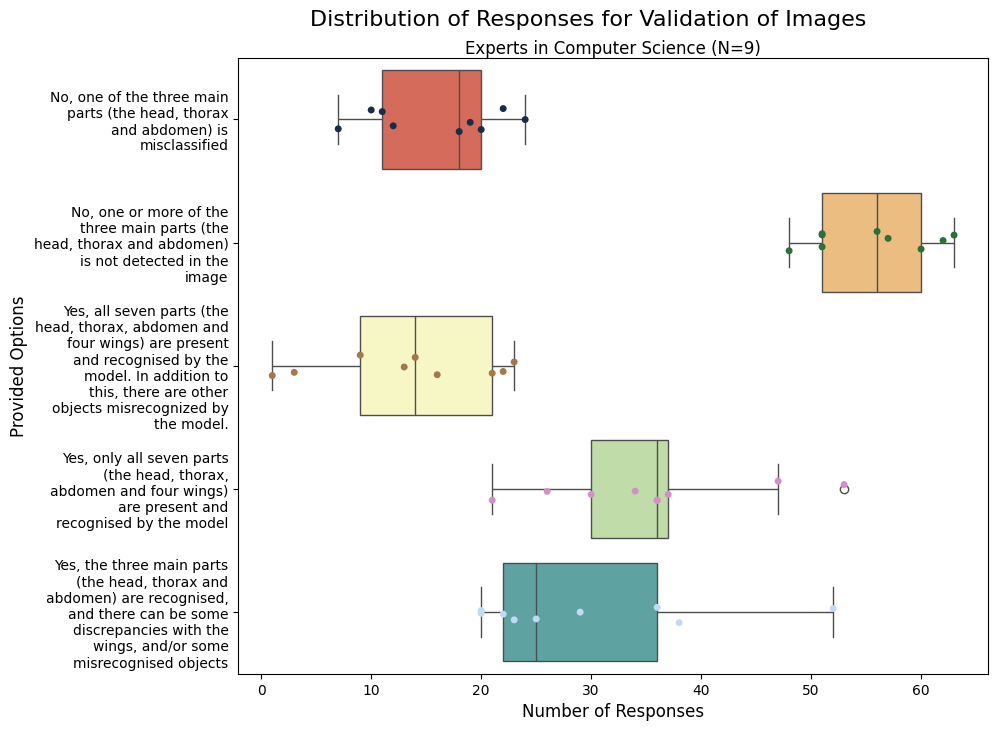

In [ ]:
fig, axs = plt.subplots(figsize=(10, 8))
sns.boxplot(ax=axs, data=total_of_responses_cs,zorder=0, orient='h', palette='Spectral')
sns.stripplot(ax=axs, data=total_of_responses_cs, zorder=1, orient='h', palette='cubehelix')

plt.suptitle("Distribution of Responses for Validation of Images", fontsize=16, y=0.94)
axs.set_title("Experts in Computer Science (N=9)", fontsize=12, pad=2)

axs.set_xlabel("Number of Responses", fontsize=12)
axs.set_ylabel("Provided Options", fontsize=12)
labels = [textwrap.fill(label.get_text(), max_width) for label in axs.get_yticklabels()]
ticks = axs.get_yticks()
axs.set_yticks(ticks)
axs.set_yticklabels(labels, fontsize=10)
plt.subplots_adjust(left=0.15)
plt.show()
plt.savefig("responses_distribution_cs_experts.png", dpi=300)

# Summary of Responses by Image

In [17]:
index_qa = pd.RangeIndex(start=1, stop=151)
new_index_qa = index_qa.map(lambda x: f"Image {x}")

## Bio

In [18]:
summary_of_responses_bio = experts_biology_df.apply(pd.Series.value_counts, axis=0).fillna(0)
summary_of_responses_bio = summary_of_responses_bio.transpose()
summary_of_responses_bio.set_index(new_index_qa, inplace=True)

In [19]:
summary_of_responses_bio.head(5)

,"No, one of the three main parts (the head, thorax and abdomen) is misclassified","No, one or more of the three main parts (the head, thorax and abdomen) is not detected in the image","Yes, all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model. In addition to this, there are other objects misrecognized by the model.","Yes, only all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model","Yes, the three main parts (the head, thorax and abdomen) are recognised, and there can be some discrepancies with the wings, and/or some misrecognised objects"
Image 1,0.0,0.0,0.0,0.0,9.0
Image 2,0.0,4.0,0.0,0.0,5.0
Image 3,0.0,0.0,0.0,7.0,2.0
Image 4,0.0,8.0,0.0,0.0,1.0
Image 5,2.0,0.0,4.0,0.0,3.0


In [21]:
matrix_bio = summary_of_responses_bio.values 

row_sums_bio = matrix_bio.sum(axis=1)
max_raters_bio = row_sums_bio.max()
bad_rows_bio = np.where(row_sums_bio != max_raters_bio)[0]

print("Rows with incorrect number of ratings:", bad_rows_bio)
print("Number of responses:", row_sums_bio[bad_rows_bio])

Rows with incorrect number of ratings: [ 44 109]
Number of responses: [8. 8.]


## CS

In [22]:
summary_of_responses_cs = experts_cs_df.apply(pd.Series.value_counts, axis=0).fillna(0)
summary_of_responses_cs = summary_of_responses_cs.transpose()
summary_of_responses_cs.set_index(new_index_qa, inplace=True)

In [23]:
summary_of_responses_cs

,"No, one of the three main parts (the head, thorax and abdomen) is misclassified","No, one or more of the three main parts (the head, thorax and abdomen) is not detected in the image","Yes, all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model. In addition to this, there are other objects misrecognized by the model.","Yes, only all seven parts (the head, thorax, abdomen and four wings) are present and recognised by the model","Yes, the three main parts (the head, thorax and abdomen) are recognised, and there can be some discrepancies with the wings, and/or some misrecognised objects"
Image 1,0.0,0.0,1.0,0.0,8.0
Image 2,0.0,0.0,0.0,2.0,7.0
Image 3,0.0,0.0,0.0,9.0,0.0
Image 4,1.0,4.0,2.0,0.0,2.0
Image 5,1.0,0.0,6.0,2.0,0.0
...,...,...,...,...,...
Image 146,1.0,8.0,0.0,0.0,0.0
Image 147,0.0,4.0,0.0,1.0,4.0
Image 148,1.0,8.0,0.0,0.0,0.0
Image 149,0.0,5.0,0.0,2.0,2.0


In [24]:
matrix_cs = summary_of_responses_cs.values 

row_sums_cs = matrix_cs.sum(axis=1)
max_raters_cs = row_sums_cs.max()
bad_rows_cs = np.where(row_sums_cs != max_raters_cs)[0]

print("Rows with incorrect number of ratings:", bad_rows_cs)
print("Number of responses:", row_sums_cs[bad_rows_cs])

Rows with incorrect number of ratings: [8]
Number of responses: [8.]


# Fleiss' Kappa Calculation

In [28]:
clean_matrix_bio = matrix_bio[row_sums_bio == max_raters_bio]
kappa_value_bio = fleiss_kappa(clean_matrix_bio, method='fleiss')
print("Fleiss' Kappa:", np.round(kappa_value_bio, 4))

Fleiss' Kappa: 0.5832


In [27]:
clean_matrix_cs = matrix_cs[row_sums_cs == max_raters_cs]
kappa_value_cs = fleiss_kappa(clean_matrix_cs, method='fleiss')
print("Fleiss' Kappa:", np.round(kappa_value_cs, 4))

Fleiss' Kappa: 0.4797
